In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

1,383,526 observations, 133 colonnes


In [3]:
x_train, x_test, y_train, y_test = split_data(df)

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  28.2s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  28.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  41.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.2min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.5min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  33.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.6min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=

/opt/python/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time= 2.9min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time= 2.4min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  54.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time= 1.6min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 3.1min
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 4.1min
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time= 1.5min
[CV] END max_depth=30, max_features=l

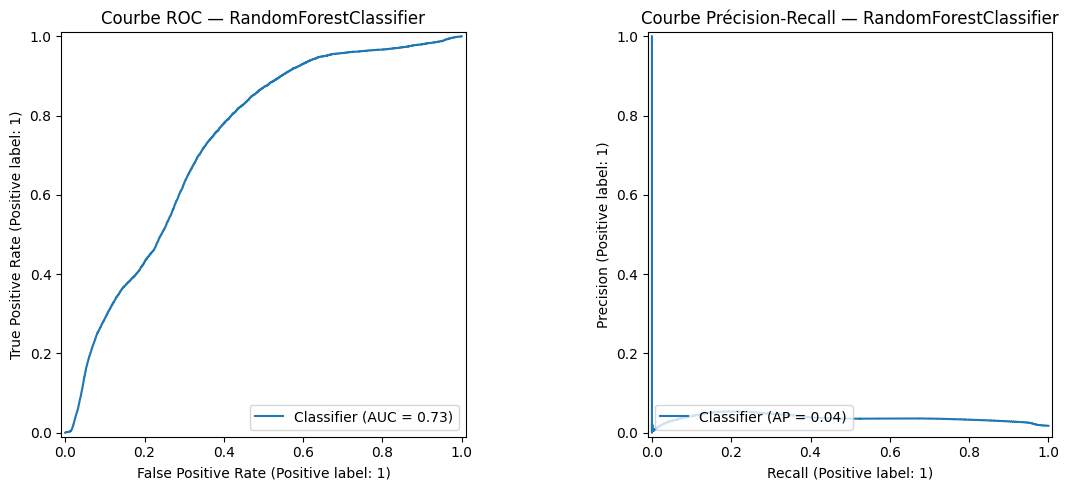

In [4]:
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.3],
}

model_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=model_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

search.fit(x_train, y_train)

print(f'\nMeilleurs paramètres : {search.best_params_}')
print(f'Meilleure AUC en CV  : {search.best_score_:.4f}')

best_model = search.best_estimator_
metrics = evaluate(best_model, x_test, y_test)

In [6]:
save_model(best_model,'random_forest_insee')

Modèle sauvegardé dans models/random_forest_insee.pkl


'models/random_forest_insee.pkl'

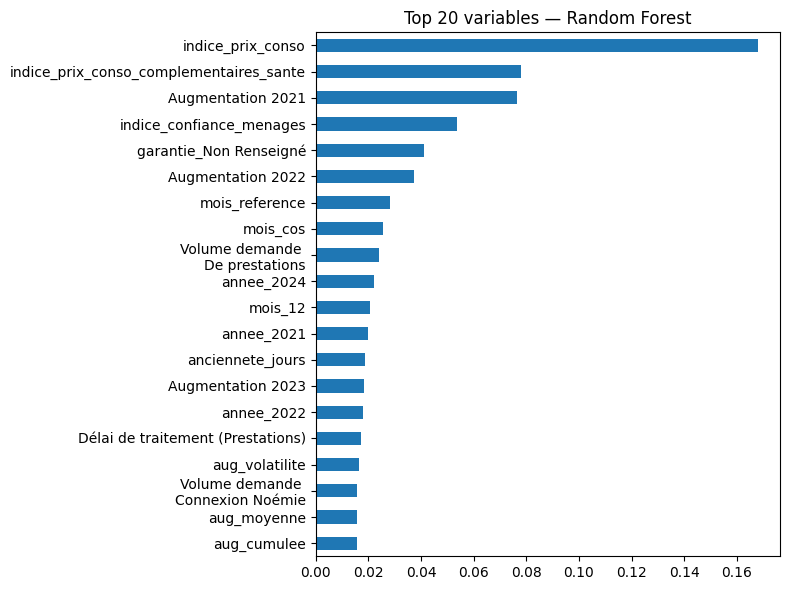

In [5]:
importances = pd.Series(best_model.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False).head(20).plot(
    kind='barh', figsize=(8, 6)
)
plt.title('Top 20 variables — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()